In [1]:
import pandas as pd

df = pd.read_csv('data/processed/cleaned_data.csv')
print(df.shape)
df.head()

(421570, 23)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Unemployment,Type,Size,Year,Month,Month_Name,Quarter,Week,Day,Day_Name
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,...,8.106,A,151315,2010,2,February,1,5,5,Friday
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,...,8.106,A,151315,2010,2,February,1,6,12,Friday
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,...,8.106,A,151315,2010,2,February,1,7,19,Friday
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,...,8.106,A,151315,2010,2,February,1,8,26,Friday
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,...,8.106,A,151315,2010,3,March,1,9,5,Friday


In [2]:
store_df = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
store_df = store_df.sort_values('Date')
print(store_df.shape)
store_df[['Date', 'Weekly_Sales']].head()

(143, 23)


,Date,Weekly_Sales
0,2010-02-05,24924.50
1,2010-02-12,46039.49
2,2010-02-19,41595.55
3,2010-02-26,19403.54
4,2010-03-05,21827.90


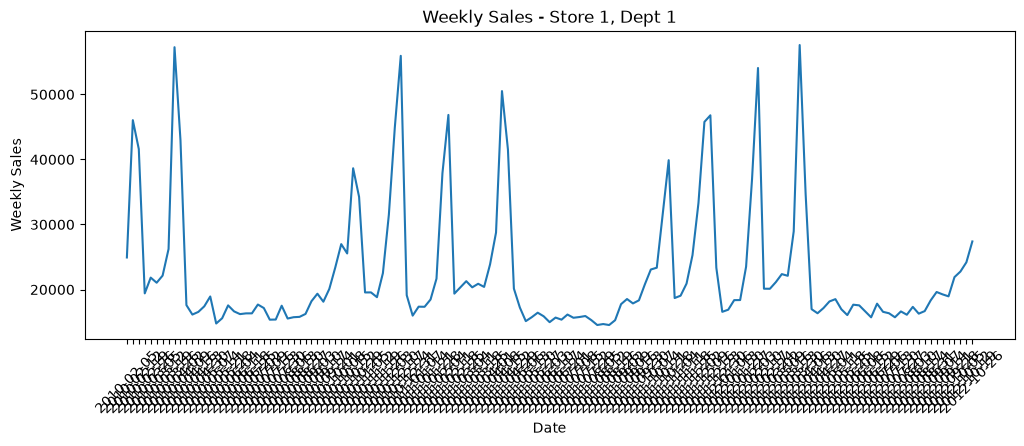

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(store_df['Date'], store_df['Weekly_Sales'])
plt.title('Weekly Sales - Store 1, Dept 1')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.xticks(rotation=45)
plt.show()

In [4]:
prophet_df = store_df[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])
prophet_df.head()

,ds,y
0,2010-02-05,24924.50
1,2010-02-12,46039.49
2,2010-02-19,41595.55
3,2010-02-26,19403.54
4,2010-03-05,21827.90


Importing plotly failed. Interactive plots will not work.
21:51:38 - cmdstanpy - INFO - Chain [1] start processing
21:51:39 - cmdstanpy - INFO - Chain [1] done processing


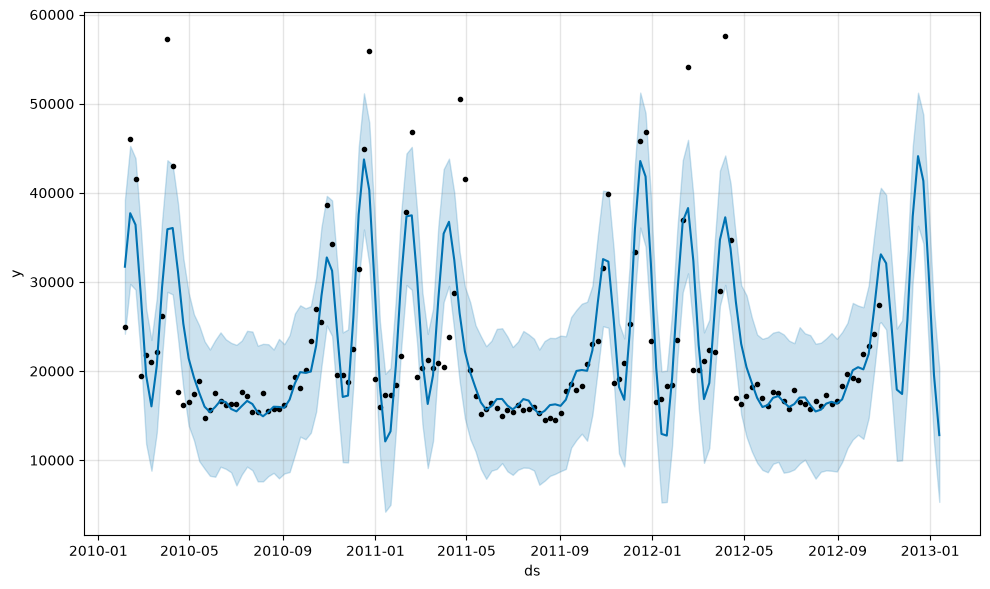

In [5]:
from prophet import Prophet

model = Prophet(yearly_seasonality=True)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=12, freq='W')
forecast = model.predict(future)

fig1 = model.plot(forecast)

In [6]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(contamination=0.05, random_state=42)
store_df['anomaly'] = iso_model.fit_predict(store_df[['Weekly_Sales']])
store_df['anomaly'] = store_df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

store_df[store_df['anomaly'] == 'Anomaly'][['Date', 'Weekly_Sales', 'IsHoliday', 'anomaly']]

,Date,Weekly_Sales,IsHoliday,anomaly
8,2010-04-02,57258.43,False,Anomaly
9,2010-04-09,42960.91,False,Anomaly
46,2010-12-24,55931.23,False,Anomaly
63,2011-04-22,50510.31,False,Anomaly
96,2011-12-09,33305.92,False,Anomaly
105,2012-02-10,36988.49,True,Anomaly
106,2012-02-17,54060.10,False,Anomaly
113,2012-04-06,57592.12,False,Anomaly


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = prophet_df['y'].values
predicted = forecast['yhat'][:len(actual)].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 3602.54
RMSE: 5845.91
